# [First Break AI ](https://cohort.bubblnet.com)
## Lesson01 : HuggingFace Beyond Upload
https://cohort.bubblnet.com/lessons/lesson-1-huggingface-beyond-upload

### **Learning Comment: Data Loading and Initial Inspection**

This cell demonstrates how to load a dataset from the Hugging Face `datasets` library, convert it into a pandas DataFrame, and perform an initial inspection.

1.  **`!pip install -q datasets pandas matplotlib duckdb`**: Installs essential Python libraries.
    *   `datasets`: For easily loading and working with various datasets from the Hugging Face Hub.
    *   `pandas`: A powerful library for data manipulation and analysis, especially with DataFrames.
    *   `matplotlib`: A fundamental library for creating static, interactive, and animated visualizations.
    *   `duckdb`: A fast in-process analytical database, often used for data analysis directly within Python environments (though not explicitly used for data processing in this specific snippet, it's installed for potential future use).
2.  **`from datasets import load_dataset`**: Imports the function to load datasets.
3.  **`import pandas as pd`**: Imports pandas, aliasing it as `pd` for convenience.
4.  **`import matplotlib.pyplot as plt`**: Imports the plotting module from matplotlib, aliasing it as `plt`.
5.  **`dataset_name = "databricks/databricks-dolly-15k"`**: Defines the name of the dataset to be loaded. This dataset contains instruction-following records generated by Databricks.
6.  **`ds = load_dataset(dataset_name, split="train")`**: Loads the 'train' split of the specified dataset from the Hugging Face Hub into a `Dataset` object.
7.  **`df = ds.to_pandas()`**: Converts the loaded `Dataset` object into a pandas DataFrame, which is a common and flexible structure for data analysis.
8.  **`print(df.shape)`**: Prints the dimensions (number of rows, number of columns) of the DataFrame, giving you an immediate idea of its size.
9.  **`df.head()`**: Displays the first 5 rows of the DataFrame, allowing for a quick preview of the data's structure and content.

| Dataset                           | Why students should inspect it                                                  | What to analyze                                                                          |
| :-------------------------------- | :------------------------------------------------------------------------------ | :--------------------------------------------------------------------------------------- |
| `HuggingFaceFW/fineweb`           | Pretraining-style web corpus; cleaned and deduplicated Common Crawl text        | text length, source distribution, language quality, duplicate patterns, crawl snapshots  |
| `fineweb10B-gpt2`                 | This is primary data set we will use in our experiments .                       | similar to first fineweb                                                                |
| `HuggingFaceH4/ultrachat_200k`    | SFT/chat-style dataset used in Zephyr-style training workflows                  | prompt/response length, conversation turns, train/test splits, short/low-quality prompts |
| `OpenAssistant/oasst1`            | Human-generated assistant conversation trees with multilingual data and ratings | role alternation, languages, ratings, conversation structure                             |
| `databricks/databricks-dolly-15k` | Small instruction-tuning dataset; easy to inspect fully in class                | categories, instruction/context/response lengths, missing context, task diversity        |

# Dataset : databricks/databricks-dolly-15k

In [ ]:
!pip install -q datasets pandas matplotlib duckdb

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

dataset_name = "databricks/databricks-dolly-15k"

ds = load_dataset(dataset_name, split="train")
df = ds.to_pandas()

print(df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

(15011, 4)


,instruction,context,response,category
0,When did Virgin Australia start operating?,"Virgin Australia, the trading name of Virgin A...",Virgin Australia commenced services on 31 Augu...,closed_qa
1,Which is a species of fish? Tope or Rope,,Tope,classification
2,Why can camels survive for long without water?,,Camels use the fat in their humps to keep them...,open_qa
3,"Alice's parents have three daughters: Amy, Jes...",,The name of the third daughter is Alice,open_qa
4,When was Tomoaki Komorida born?,Komorida was born in Kumamoto Prefecture on Ju...,"Tomoaki Komorida was born on July 10,1981.",closed_qa


In [1]:
!pip install -q datasets pandas matplotlib duckdb

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt

dataset_name = "databricks/databricks-dolly-15k"

ds = load_dataset(dataset_name, split="train")
df = ds.to_pandas()

print(df.shape)
df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

databricks-dolly-15k.jsonl:   0%|          | 0.00/13.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15011 [00:00<?, ? examples/s]

(15011, 4)


,instruction,context,response,category
0,When did Virgin Australia start operating?,"Virgin Australia, the trading name of Virgin A...",Virgin Australia commenced services on 31 Augu...,closed_qa
1,Which is a species of fish? Tope or Rope,,Tope,classification
2,Why can camels survive for long without water?,,Camels use the fat in their humps to keep them...,open_qa
3,"Alice's parents have three daughters: Amy, Jes...",,The name of the third daughter is Alice,open_qa
4,When was Tomoaki Komorida born?,Komorida was born in Kumamoto Prefecture on Ju...,"Tomoaki Komorida was born on July 10,1981.",closed_qa


### **Initial Data Inspection - Columns, Types, and Missing Values**

This cell performs a quick, essential initial inspection of the DataFrame (`df`) to understand its structure and data quality. This is a crucial step in any data analysis workflow to identify potential issues before further processing.

1.  **`print(df.columns)`**: This line prints the names of all columns present in the DataFrame. Understanding the column names helps in knowing what data points are available and how to reference them.
2.  **`print(df.dtypes)`**: This line displays the data type of each column. Data types are critical as they dictate what operations can be performed on a column. For instance, 'object' often indicates strings, while 'int64' or 'float64' indicate numerical data. Mismatched data types can lead to errors or incorrect analysis.
3.  **`print(df.isna().sum())`**: This line calculates the number of missing (NaN) values for each column. `df.isna()` returns a boolean DataFrame where `True` indicates a missing value. `.sum()` then counts these `True` values column-wise. Identifying missing values is important for deciding on a strategy to handle them (e.g., imputation, removal) to prevent bias or errors in subsequent analysis.

In [2]:
print(df.columns)
print(df.dtypes)
print(df.isna().sum())

Index(['instruction', 'context', 'response', 'category'], dtype='object')
instruction    object
context        object
response       object
category       object
dtype: object
instruction    0
context        0
response       0
category       0
dtype: int64


### **Analyze instruction categories**

In [3]:
df["category"].value_counts()

,count
category,
open_qa,3742
general_qa,2191
classification,2136
closed_qa,1773
brainstorming,1766
information_extraction,1506
summarization,1188
creative_writing,709


### **Analyze length distribution**


In [4]:
df["instruction_chars"] = df["instruction"].str.len()
df["response_chars"] = df["response"].str.len()
df["context_chars"] = df["context"].fillna("").str.len()

df[["instruction_chars", "response_chars", "context_chars"]].describe()

,instruction_chars,response_chars,context_chars
count,15011.000000,15011.000000,15011.000000
mean,71.839384,358.104190,352.898808
std,134.679885,591.581031,956.289456
min,4.000000,1.000000,0.000000
25%,37.000000,78.000000,0.000000
50%,54.000000,186.000000,0.000000
75%,81.000000,430.000000,408.000000
max,11698.000000,26018.000000,23505.000000


### **Plot**

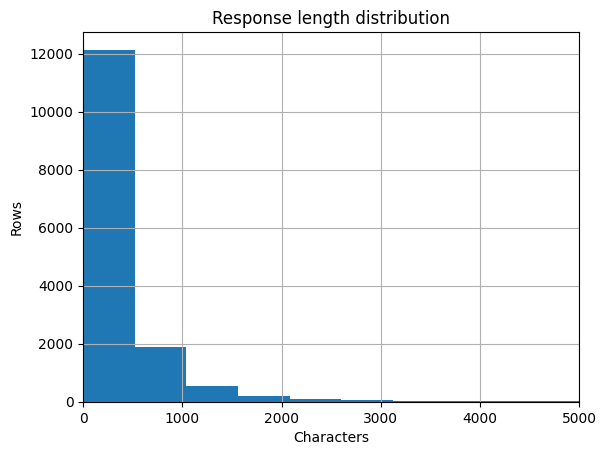

In [8]:
df["response_chars"].hist(bins=50)
plt.title("Response length distribution")
plt.xlabel("Characters")
plt.ylabel("Rows")
plt.xlim(0, 5000) # Set x-axis limit to 5000
plt.show()

### **Find short/weak examples:**

In [9]:
df[df["response_chars"] < 50][["instruction", "response", "category"]].head(20)

,instruction,response,category
1,Which is a species of fish? Tope or Rope,Tope,classification
3,"Alice's parents have three daughters: Amy, Jes...",The name of the third daughter is Alice,open_qa
4,When was Tomoaki Komorida born?,"Tomoaki Komorida was born on July 10,1981.",closed_qa
7,Who gave the UN the land in NY to build their HQ,John D Rockerfeller,open_qa
12,From the passage list down the areas for which...,"arts, fashion, media, film, television, finance",information_extraction
19,Identify which instrument is string or percuss...,"Gudok is string, Cantaro is percussion.",classification
20,Give me the top 5 golf equipment company names.,"Titleist, Taylormade, Callaway, Ping, Cobra",brainstorming
22,Which Dutch artist painted “Girl with a Pearl ...,Vermeer,open_qa
23,What happens when the sun goes down?,"When the sun sets, the evening starts.",open_qa
27,Identify which instrument is string or woodwin...,"Zurna is woodwind, Panduri is string.",classification


### **Find very long examples:**

In [10]:
df.sort_values("response_chars", ascending=False)[
    ["instruction", "response", "category", "response_chars"]
].head(10)

,instruction,response,category,response_chars
1867,What is a console war in video games?,The video game console market started in 1972 ...,summarization,26018
12060,What is the concept of a good life according t...,One of the most tantalizing and theorized abou...,creative_writing,9796
9541,What is the best modern motorcycle for a begin...,If you have no or little experience with motor...,general_qa,8881
4786,What is the difference between the right and l...,The lateralization of brain function is the te...,summarization,8832
14186,Give me a list of the dog breeds,Affenpinscher\nAfghan Hound\nAfricanis\nAidi\n...,summarization,8822
76,What is HiFI?,Bell Laboratories began experimenting with a r...,information_extraction,8736
5497,"Explain how ""work from home"" has an opportunit...","These days, it is “cool” to be a techie. Jobs ...",creative_writing,8167
7498,Write a short story about a little girl that s...,Milly was 6 years old and ever since she could...,creative_writing,7951
6768,What should I look for when looking for a used...,Items to look for when looking to purchase a u...,creative_writing,7926
8292,How do we increase voter turnout in the United...,Voter turnout in the United States varies from...,general_qa,7888
